In [1]:
import pandas as pd

In [2]:
books = pd.read_csv(
    r"Books.csv",
    encoding='latin1'
)

users = pd.read_csv(
    r"Users.csv",
    encoding='latin1'
)

ratings = pd.read_csv(
    r"Ratings.csv",
    encoding='latin1'
)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24320\2963704931.py:1: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv(


# Lets merge files 

In [7]:
print("Books columns:")
print(books.columns)

print("\nUsers columns:")
print(users.columns)

print("\nRatings columns:")
print(ratings.columns)

Books columns:
Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='str')

Users columns:
Index(['User-ID', 'Location', 'Age'], dtype='str')

Ratings columns:
Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='str')


In [3]:
df = ratings.merge(books, on='ISBN', how='inner')

df = df.merge(users, on='User-ID', how='inner')

df.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",NaN
1,276726,155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa",NaN
2,276727,446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia",16.0
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia",16.0
4,276729,521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia",16.0


In [4]:
df.shape

(941112, 12)

In [5]:
df.isnull().sum()

User-ID                     0
ISBN                        0
Book-Rating                 0
Book-Title                  0
Book-Author                 2
Year-Of-Publication         0
Publisher                   2
Image-URL-S                 0
Image-URL-M                 0
Image-URL-L                 4
Location                    0
Age                    255641
dtype: int64

# Fill missing ages with median age.

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fix missing values of author, publisher and Image

In [15]:
df['Book-Author'] = df['Book-Author'].fillna('Unknown')

In [16]:
df['Publisher'] = df['Publisher'].fillna('Unknown')

In [17]:
df['Image-URL-L'] = df['Image-URL-L'].fillna('No Image')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 941112 entries, 0 to 941111
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   User-ID              941112 non-null  int64  
 1   ISBN                 941112 non-null  str    
 2   Book-Rating          941112 non-null  int64  
 3   Book-Title           941112 non-null  str    
 4   Book-Author          941110 non-null  str    
 5   Year-Of-Publication  941112 non-null  object 
 6   Publisher            941110 non-null  str    
 7   Image-URL-S          941112 non-null  str    
 8   Image-URL-M          941112 non-null  str    
 9   Image-URL-L          941108 non-null  str    
 10  Location             941112 non-null  str    
 11  Age                  941112 non-null  float64
dtypes: float64(1), int64(2), object(1), str(8)
memory usage: 334.0+ MB


# Rating Distribution`

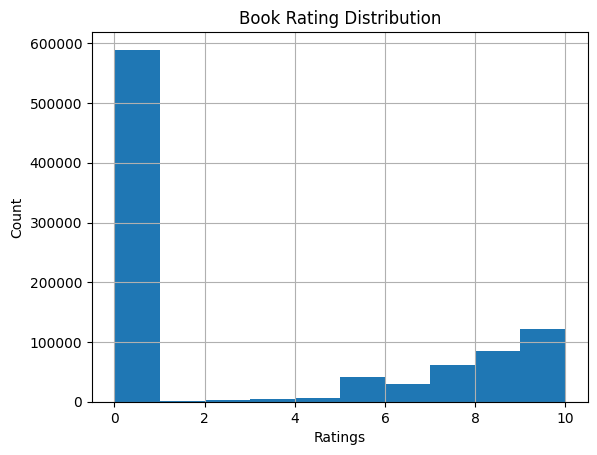

In [9]:
import matplotlib.pyplot as plt

df['Book-Rating'].hist(bins=10)

plt.title("Book Rating Distribution")

plt.xlabel("Ratings")

plt.ylabel("Count")

plt.show()

In [ ]:
# The majority of records have a rating of 0 suggesting many users didnot rate reports.
 # Among non-zero ratings, most ratings lie between 7 and 10.
# It is not normally distributed, distribution is heavily left-skewed

In [ ]:
# Top 10 Most Rated Books

In [10]:
top_books = df.groupby('Book-Title')['Book-Rating'].count()

top_books.sort_values(ascending=False).head(10)

Book-Title
Wild Animus                                        2264
The Lovely Bones: A Novel                          1164
The Da Vinci Code                                   828
A Painted House                                     766
The Nanny Diaries: A Novel                          759
Bridget Jones's Diary                               740
The Secret Life of Bees                             704
Divine Secrets of the Ya-Ya Sisterhood: A Novel     669
The Red Tent (Bestselling Backlist)                 668
Angels &amp; Demons                                 616
Name: Book-Rating, dtype: int64

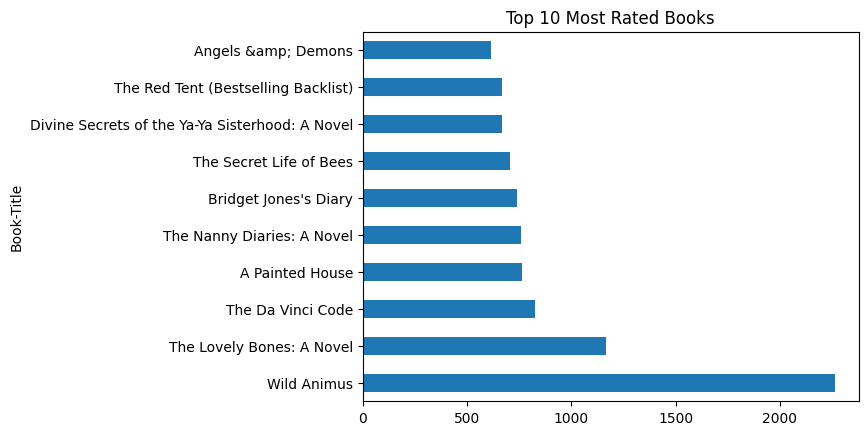

In [11]:
top_books.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Most Rated Books")
plt.show()

In [ ]:
# Top Authors

In [12]:
df['Book-Author'].value_counts().head(10)

Book-Author
Stephen King          9075
Nora Roberts          7737
John Grisham          5469
James Patterson       5295
Mary Higgins Clark    4409
Dean R. Koontz        3948
Tom Clancy            3591
Danielle Steel        3421
Sue Grafton           3151
Janet Evanovich       3107
Name: count, dtype: int64

In [ ]:
# Top Publishers

In [13]:
df['Publisher'].value_counts().head(10)

Publisher
Ballantine Books            31562
Pocket                      29143
Berkley Publishing Group    25881
Warner Books                23169
Harlequin                   22540
Bantam Books                21468
Bantam                      18231
Signet Book                 17462
Avon                        15804
Penguin Books               15504
Name: count, dtype: int64

In [ ]:
# User Age Distribution

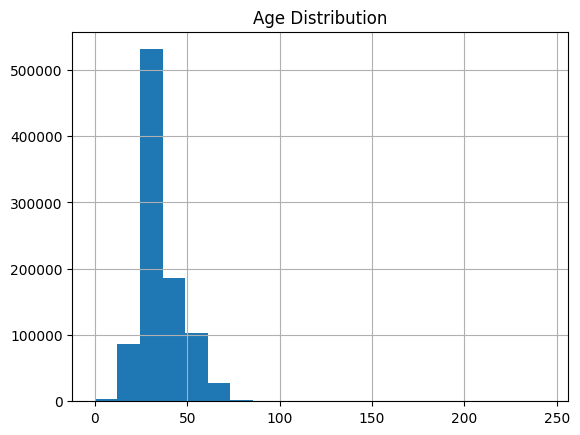

In [14]:
df['Age'].hist(bins=20)

plt.title("Age Distribution")

plt.show()

<Axes: >

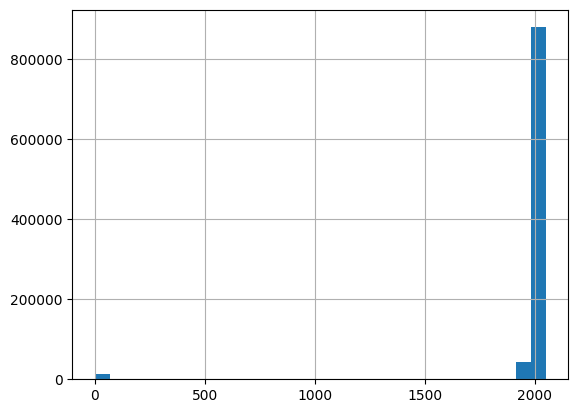

In [32]:
df['Year-Of-Publication'].hist(bins=30)

In [ ]:
# Most users are between 25 and 50 years old

In [ ]:
# Top Locations

In [19]:
df['Location'].value_counts().head(10)

Location
toronto, ontario, canada         13023
n/a, n/a, n/a                    11165
ottawa, ontario, canada           7890
chicago, illinois, usa            7623
olympia, washington, usa          7587
omaha, nebraska, usa              7125
st. louis, missouri, usa          6959
little canada, minnesota, usa     6458
duluth, minnesota, usa            6165
seattle, washington, usa          6103
Name: count, dtype: int64

# Detect Outliers in Age

In [20]:
df['Age'].describe()

count    941112.000000
mean         37.224391
std          12.145128
min           0.000000
25%          31.000000
50%          36.000000
75%          41.000000
max         244.000000
Name: Age, dtype: float64

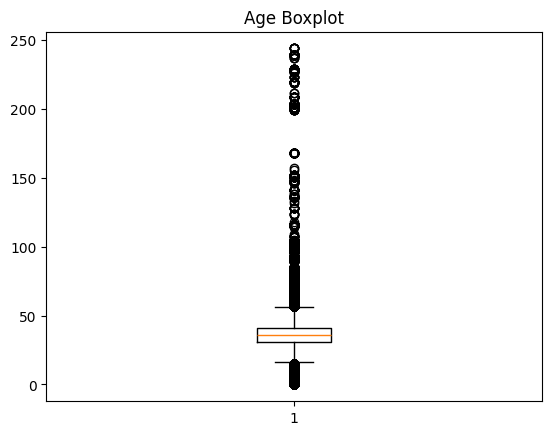

In [21]:
import matplotlib.pyplot as plt

plt.boxplot(df['Age'].dropna())

plt.title("Age Boxplot")

plt.show()

In [ ]:
# Remove Unrealistic Ages

In [22]:
df = df[(df['Age'] >= 5) & (df['Age'] <= 100)]

In [ ]:
# checking outliers in Year-Of-Publication

In [24]:
print(df['Year-Of-Publication'].dtype)

object


In [25]:
df['Year-Of-Publication'] = pd.to_numeric(
    df['Year-Of-Publication'],
    errors='coerce'
)

In [26]:
df['Year-Of-Publication'].describe()

count    936809.000000
mean       1968.310443
std         230.558479
min           0.000000
25%        1992.000000
50%        1997.000000
75%        2001.000000
max        2050.000000
Name: Year-Of-Publication, dtype: float64

In [30]:
df['Year-Of-Publication'].sort_values().head(10)

44        0.0
340639    0.0
423748    0.0
53188     0.0
680768    0.0
154421    0.0
236253    0.0
154488    0.0
941061    0.0
940840    0.0
Name: Year-Of-Publication, dtype: float64

In [31]:
df['Year-Of-Publication'].sort_values().tail(10)

310129    2050.0
164042    2050.0
896777    2050.0
169061    2050.0
288365    2050.0
609047    2050.0
488855       NaN
511782       NaN
622767       NaN
842845       NaN
Name: Year-Of-Publication, dtype: float64

In [29]:
invalid_years = df[
    (df['Year-Of-Publication'] < 1900) |
    (df['Year-Of-Publication'] > 2025)
]

print(invalid_years.shape)

(12722, 12)
